# 06 - The full 27-qubit encoding

**Goal:** show that GQE reaches the exact ViennaRNA MFE of **-7.90 kcal/mol**
when nothing is trimmed away.

Notebook 02 uses 22 qubits, which drops a few stems and leaves a small gap.
Here we keep all 27 stems, so the encoding is exact and the only question is
whether training can find the optimum.

This is the largest instance that fits on a free T4. The statevector alone is
1.07 GB, so we run a small batch and let the phase vectors be recomputed
instead of cached.

### How to run this notebook

**Step 1 should be done in notebook 01, start from step 2 and the notebooks should run in order, 01 first then 02 till 06**

1. Put **gqe-rna.zip** at the top level of your Google Drive. Do not unzip it.
2. In Colab: **File -> Upload notebook** and pick this file.
3. **Runtime -> Change runtime type -> T4 GPU**.
4. Run notebook **01** first if you have not: this one needs its reference MFE.
5. **Runtime -> Run all**. Expect about 40 minutes.

Nothing is saved from this notebook. It is a standalone demonstration.

In [ ]:
# STEP 1 - Connect to Drive and find the project.
import sys, os, glob, subprocess, importlib

from google.colab import drive
drive.mount("/content/drive")

ROOT = "/content/drive/MyDrive"
REPO = os.path.join(ROOT, "gqe-rna")

if not os.path.isdir(os.path.join(REPO, "src")):
    zp = os.path.join(ROOT, "gqe-rna.zip")
    assert os.path.exists(zp), (
        "gqe-rna.zip was not found at the top level of My Drive.")
    subprocess.run(["unzip", "-q", "-o", zp, "-d", ROOT], check=True)

if not os.path.isdir(os.path.join(REPO, "src")):
    hits = glob.glob(os.path.join(ROOT, "**", "src", "colab_utils.py"),
                     recursive=True)
    assert hits, "Could not find src/ anywhere in My Drive."
    REPO = os.path.dirname(os.path.dirname(hits[0]))

sys.path.insert(0, REPO)
importlib.invalidate_caches()
from src import colab_utils as cu

cu.setup(repo=REPO)
cu.install_vienna()

Mounted at /content/drive
project folder: /content/drive/MyDrive/gqe-rna
installing ViennaRNA ...


True

In [ ]:
# STEP 2 - Load the project code.
import time
import numpy as np
import torch
import matplotlib.pyplot as plt
from src import rna, energy, simulator, pools, metrics, gpt, train
from src import simulator27          # memory-lean version, this notebook only

rna.set_vienna_defaults()
device = gpt.pick_device()
print("ViennaRNA:", rna.HAVE_VIENNA, "| device:", device)
if device == "cpu":
    print("!! No GPU. 27 qubits on CPU is not practical.")
    print("   Runtime -> Change runtime type -> T4 GPU.")

ViennaRNA: True | device: cuda


## The sequence and its reference answer

This is the example sequence from the challenge brief.

In [ ]:
saved = cu.require("refs", made_by="01")
seq = saved["sequences"]["challenge44"]
ref_db, ref_e = saved["refs"]["challenge44"]

print("sequence     :", seq)
print("ViennaRNA MFE:", ref_db)
print("target energy:", round(ref_e, 2), "kcal/mol")

sequence     : GGAGCAAAACUUGUCGAUUGAGAACAAAAUACAGAAUUUGCUUG
ViennaRNA MFE: .(((((((..((((...(((....)))...))))..))))))).
target energy: -7.9 kcal/mol


## The full stem set: no trimming

`max_n=27` keeps every stem of length 3 or more. Nothing is discarded, so every
helix of the true MFE is representable and the encoding error is zero.

In [ ]:
MIN_LEN = 3
stems, h, J = rna.build_encoding(seq, min_len=MIN_LEN, max_n=27)
n = len(stems)

print()
missing = rna.check_mfe_coverage(seq, stems, ref_db=ref_db)

min_len=3: 27 stems found
-> 27 qubits

  helix   1- 42 length 7   in our stem set
  helix  10- 33 length 4   in our stem set
  helix  17- 26 length 3   in our stem set

  All MFE helices are representable. Any gap is now the
  optimiser's or the two-body approximation's, not coverage.


In [ ]:
# Energy of all 2^n bitstrings. float32 at this size: 0.54 GB instead of 1.07.
t0 = time.time()
E = energy.full_energy_vector(h, J, dtype=energy.pick_dtype(n))
print(f"built {len(E):,} energies in {time.time()-t0:.0f}s"
      f"  ({E.nbytes/1e9:.2f} GB)")

E_opt = float(E.min())
print("QUBO optimum:", round(E_opt, 2))
print("valid structures:", int((E < 0).sum()), "of", f"{len(E):,}")

built 134,217,728 energies in 41s  (0.54 GB)
QUBO optimum: -10.4
valid structures: 14 of 134,217,728


## What does this instance cost?

The numbers the challenge asks for: qubits, variables, gates, depth, and what
that would mean on real hardware.

In [ ]:
n_terms = int((J > 0).sum() + (J < 0).sum())     # non-zero quadratic terms
SEQ_LEN = 16                                     # gates the model may use

print(f"{'RNA length':<32}{len(seq):>12}")
print(f"{'candidate stems = qubits':<32}{n:>12}")
print(f"{'binary variables':<32}{n:>12}")
print(f"{'search space (2^n)':<32}{2**n:>12,}")
print(f"{'QUBO quadratic terms':<32}{n_terms:>12}")
print(f"{'gates per circuit':<32}{SEQ_LEN:>12}")
print()
print("If a cost layer were compiled to hardware:")
print(f"{'  ZZ rotations per cost layer':<32}{n_terms:>12}")
print(f"{'  CNOTs per cost layer':<32}{2*n_terms:>12}")
print(f"{'  depth per mixer layer':<32}{1:>12}")
print()
print("Simulation memory:")
print(f"{'  one statevector':<32}{(1<<n)*8/1e9:>11.2f} GB")
print(f"{'  energy vector':<32}{E.nbytes/1e9:>11.2f} GB")

RNA length                                44
candidate stems = qubits                  27
binary variables                          27
search space (2^n)               134,217,728
QUBO quadratic terms                     339
gates per circuit                         16

If a cost layer were compiled to hardware:
  ZZ rotations per cost layer            339
  CNOTs per cost layer                   678
  depth per mixer layer                    1

Simulation memory:
  one statevector                      1.07 GB
  energy vector                        0.54 GB


## Setting up the simulator

Two things change at 27 qubits:

- **Small batch.** Each statevector is 1.07 GB, so we run 2 circuits at a time
  instead of 16.
- **No phase cache.** Caching `exp(-i*gamma*E)` would cost 1.07 GB per gamma.
  Above 24 qubits the simulator recomputes it instead, which takes a few
  milliseconds on GPU and saves gigabytes.

We keep the same two tricks that made the 22-qubit run work: group mixers and a
warm start.

In [ ]:
SHOTS     = 32768      # measurement budget, reported with every result
N_SAMPLE  = 2         # circuits per epoch (memory bound at 27 qubits)
                      # each statevector is 1.07 GB, so keep this small.
                      # Sim.run() splits anything larger automatically.
GAMMAS    = [0.15, 0.3, 0.6, 1.2, 2.4, 4.8]

E_scaled, span = simulator.scale_energies(E)
pool   = pools.make_pool(gammas=GAMMAS, n_qubits=n, groups=4)
init_p = pools.warm_start_probs(h)

sim = simulator27.Sim(E_scaled, E, pool, K=4096, batch=N_SAMPLE,
                    init_probs=init_p, shots=SHOTS)

print(f"{n} qubits | {pool['size']} tokens | {N_SAMPLE} circuits per epoch")
print(f"phase caching: {sim.cache_phases} | about {sim.memory_gb():.1f} GB GPU")
print(f"backend: {sim.backend} | CVaR alpha: {sim.alpha:.2e}")

27 qubits | 24 tokens | 2 circuits per epoch
phase caching: False | about 3.8 GB GPU
backend: torch | CVaR alpha: 5.00e-04


## Offline warm-up

Short on purpose. Offline learns to predict random circuits, which is a useful
starting point but cannot search. Notebook 03 shows this clearly: loss falls
five-fold while `opt_rate` stays at 0%.

In [ ]:
N_OFFLINE = 96

t0 = time.time()
tok_np, en_np = train.make_offline_dataset(sim, N_OFFLINE, SEQ_LEN,
                                           batch=N_SAMPLE, seed=0, verbose=False)
print(f"scored {N_OFFLINE} circuits in {time.time()-t0:.0f}s")

scored 96 circuits in 703s


In [ ]:
model = gpt.GPTQE(vocab_size=pool["size"]+1, block_size=SEQ_LEN,
                  n_layer=4, n_head=4, n_embd=128, dropout=0.1).to(device)
print("parameters:", f"{model.n_params()/1e6:.2f}M")

hist_off, evals_off = train.train_offline(
    model, tok_np, en_np, epochs=80, batch=64, device=device,
    log_every=20, sim=sim, seq_len=SEQ_LEN, eval_every=20, n_eval=4)

parameters: 0.80M
  offline epoch   20  loss   288.4786   CVaR   32.70  opt_rate   0.0%  valid  0.0%
  offline epoch   40  loss   143.4040   CVaR   29.53  opt_rate   0.0%  valid  0.0%
  offline epoch   60  loss    99.1252   CVaR   34.19  opt_rate   0.0%  valid  0.0%
  offline epoch   80  loss    81.8535   CVaR   33.23  opt_rate   0.0%  valid  0.0%

  ----------------------------------------------------
  offline training finished: 80 epochs
  loss           : 893.2 -> 81.9
  best energy    : 2.300   (optimum -10.400)
  CVaR           : 31.22 -> 33.23
  opt_rate       : 0.0% -> 0.0%
  ----------------------------------------------------


As we can see, at bigger circuits, the offline training failed to find the minimum while for 22 qubits before it was able but with low probability. This shows the importance of online training which is able to find and reach 100%!

## Online training

The model proposes circuits, we score them, it learns from the result.

Watch **opt_rate**: the fraction of circuits that reach the optimum. It cannot
saturate until the model is perfect, so it is the honest picture of learning.
`best` is deliberately not printed each epoch; it is a running minimum and
freezes as soon as any circuit gets lucky. It is reported at the end.

In [ ]:
t_start = time.time()
hist, best_tokens, best_index = train.train_online(
    model, sim, SEQ_LEN,
    epochs=1300, n_sample=N_SAMPLE, batch=48, n_iter=3,
    device=device, temperature=1.0,
    loss_kind="logit", log_every=25, time_budget=5000)
online_seconds = time.time() - t_start

  temp_decay set to 0.9971 (reaches 0.05 at epoch 1040)
  epoch   25  CVaR25   30.00  opt_rate25  20.0%  valid 98.0%  T 0.931  (271s)
  epoch   50  CVaR25   18.08  opt_rate25  54.0%  valid 98.0%  T 0.866  (411s)
  epoch   75  CVaR25   -1.13  opt_rate25  40.0%  valid 100.0%  T 0.806  (477s)
  epoch  100  CVaR25   -2.92  opt_rate25  40.0%  valid 100.0%  T 0.750  (536s)
  epoch  125  CVaR25   -3.54  opt_rate25  40.0%  valid 100.0%  T 0.698  (596s)
  epoch  150  CVaR25   -3.62  opt_rate25  52.0%  valid 100.0%  T 0.649  (655s)
  epoch  175  CVaR25   -3.96  opt_rate25  74.0%  valid 100.0%  T 0.604  (719s)
  epoch  200  CVaR25   -3.38  opt_rate25  62.0%  valid 100.0%  T 0.562  (785s)
  epoch  225  CVaR25   -3.29  opt_rate25  58.0%  valid 100.0%  T 0.523  (849s)
  epoch  250  CVaR25   -4.11  opt_rate25  62.0%  valid 100.0%  T 0.487  (909s)
  epoch  275  CVaR25   -4.00  opt_rate25  68.0%  valid 100.0%  T 0.453  (975s)
  epoch  300  CVaR25   -3.84  opt_rate25  76.0%  valid 100.0%  T 0.421  (1038

## The result

Decode the best bitstring into a structure and score it with ViennaRNA.

Our model finds two things:

1. The minimum energy.
2. The structure from the decoded measured bitstrings.

Then compares both with ViennaRNA's results.

In [ ]:
best_bits = energy.index_to_bits(np.array([best_index]), n)[0]
db_gqe = rna.decode_bits(seq, stems, best_bits, h=h)
e_gqe = rna.eval_structure(seq, db_gqe)

print("GQE structure :", db_gqe)
print("ViennaRNA MFE :", ref_db)
print()
print(f"GQE energy    : {e_gqe:6.2f} kcal/mol")
print(f"target MFE    : {ref_e:6.2f} kcal/mol")
print(f"gap           : {e_gqe - ref_e:+6.2f} kcal/mol")
print()
row = metrics.report(seq, db_gqe, ref_db, e_gqe, ref_e)
metrics.print_row(row)
print()
if abs(e_gqe - ref_e) < 1e-6:
    print("Exact match with the ViennaRNA minimum free energy structure.")

GQE structure : .(((((((..((((...(((....)))...))))..))))))).
ViennaRNA MFE : .(((((((..((((...(((....)))...))))..))))))).

GQE energy    :  -7.90 kcal/mol
target MFE    :  -7.90 kcal/mol
gap           :  +0.00 kcal/mol

  length  44 | gap  +0.00 kcal/mol | F1 1.00 | exact True

Exact match with the ViennaRNA minimum free energy structure.


## Training curves

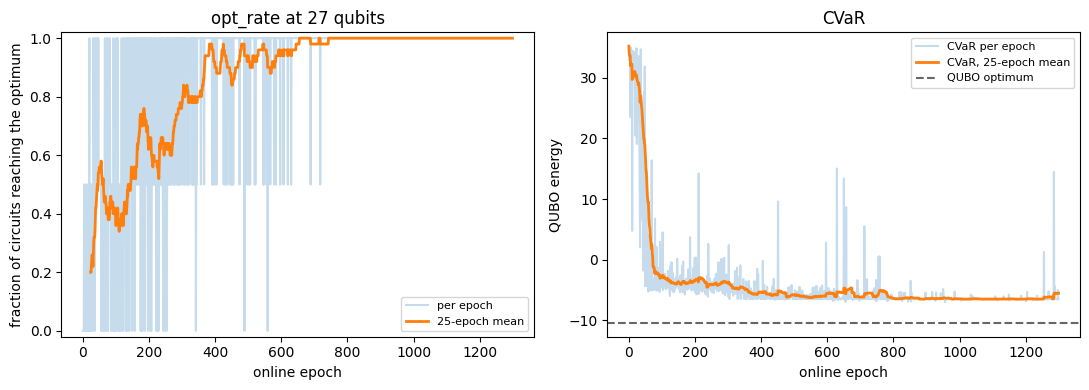

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

orr = np.array(hist["opt_rate"])
k = min(25, max(1, len(orr)//5))
sm = np.convolve(orr, np.ones(k)/k, mode="valid")
ax[0].plot(orr, alpha=0.25, label="per epoch")
ax[0].plot(np.arange(len(sm))+k-1, sm, lw=2, label=f"{k}-epoch mean")
ax[0].set_ylim(-0.02, 1.02)
ax[0].set_xlabel("online epoch")
ax[0].set_ylabel("fraction of circuits reaching the optimum")
ax[0].set_title(f"opt_rate at {n} qubits"); ax[0].legend(fontsize=8)

ax[1].plot(hist["mean_cvar"], alpha=0.25, label="CVaR per epoch")
ax[1].plot(hist["cvar_smooth"], lw=2, label="CVaR, 25-epoch mean")
ax[1].axhline(E_opt, ls="--", c="k", alpha=0.6, label="QUBO optimum")
ax[1].set_xlabel("online epoch"); ax[1].set_ylabel("QUBO energy")
ax[1].set_title("CVaR"); ax[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

## Resource summary

Everything the challenge asks for in Deliverable 6, measured rather than
estimated.

In [ ]:
epochs_run = len(hist["best"])
online_circuits = epochs_run * N_SAMPLE
total_circuits = N_OFFLINE + online_circuits
evaluations = total_circuits * SEQ_LEN          # energy read after every gate

print("PROBLEM")
print(f"  RNA length                  {len(seq)}")
print(f"  qubits (stems)              {n}")
print(f"  search space                {2**n:,}")
print(f"  valid structures            {int((E<0).sum())}")
print(f"  QUBO quadratic terms        {n_terms}")
print()
print("CIRCUIT")
print(f"  gates per circuit           {SEQ_LEN}")
print(f"  operator pool size          {pool['size']}")
print(f"  CNOTs per cost layer        {2*n_terms}")
print()
print("TRAINING")
print(f"  offline circuits            {N_OFFLINE}")
print(f"  online epochs               {epochs_run}")
print(f"  circuits per epoch          {N_SAMPLE}")
print(f"  total circuits              {total_circuits:,}")
print(f"  total energy evaluations    {evaluations:,}")
print(f"  shots per evaluation        {SHOTS:,}")
print(f"  total measurements          {evaluations*SHOTS:,}")
print(f"  online wall clock           {online_seconds/60:.1f} min")
print()
print("RESULT")
print(f"  QUBO optimum                {E_opt:.2f}")
print(f"  best found                  {hist['best'][-1]:.2f}")
print(f"  opt_rate, first 25 epochs   {np.mean(hist['opt_rate'][:25]):.1%}")
print(f"  opt_rate, last 25 epochs    {np.mean(hist['opt_rate'][-25:]):.1%}")
print(f"  ViennaRNA energy            {e_gqe:.2f} kcal/mol")
print(f"  reference MFE               {ref_e:.2f} kcal/mol")
print(f"  gap                         {e_gqe-ref_e:+.2f} kcal/mol")
print(f"  base-pair F1                {row['f1']:.2f}")

PROBLEM
  RNA length                  44
  qubits (stems)              27
  search space                134,217,728
  valid structures            14
  QUBO quadratic terms        339

CIRCUIT
  gates per circuit           16
  operator pool size          24
  CNOTs per cost layer        678

TRAINING
  offline circuits            96
  online epochs               1300
  circuits per epoch          2
  total circuits              2,696
  total energy evaluations    43,136
  shots per evaluation        32,768
  total measurements          1,413,480,448
  online wall clock           64.1 min

RESULT
  QUBO optimum                -10.40
  best found                  -10.40
  opt_rate, first 25 epochs   20.0%
  opt_rate, last 25 epochs    100.0%
  ViennaRNA energy            -7.90 kcal/mol
  reference MFE               -7.90 kcal/mol
  gap                         +0.00 kcal/mol
  base-pair F1                1.00


## What this shows

With all 27 stems kept, the encoding has no error: the QUBO optimum decodes to
exactly the ViennaRNA minimum free energy structure. Online GQE finds it.

The cost is simulation, not the method. One statevector is 1.07 GB, so we can
only run 2 circuits per epoch instead of 16. The same wall clock therefore buys
about 8x fewer circuit evaluations than the 22-qubit run in notebook 03. That
is the honest scaling limit on free-tier hardware, and it is a statement about
classical simulation rather than about the algorithm.